# Week 5: Representation and Dimensionality Report

This notebook prepares a movie-level feature matrix from the Week 3 processed dataset and applies PCA.

Goal for this step:
- load the cleaned Week 3 artifacts
- build one consolidated movie feature table
- run PCA and reconstruction checks on the prepared matrix
- generate plots and tables for the Week 5 report


## Scope for the first step

In this notebook we prepare a single feature frame at movie level using:
- catalog metadata from `movies_catalog.parquet`
- interaction aggregates from `ratings_clean.parquet`
- text signals from `tags_clean.parquet`
- categorical genre structure from `movie_genres.parquet`

PCA is included in the notebook after the feature frame is built.


In [1]:
from pathlib import Path

import polars as pl

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(80)

PROJECT_ROOT = Path('..').resolve()
# PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed' / 'week03_v1'
PROCESSED_DIR = Path('/content')
INTERIM_DIR = PROJECT_ROOT / 'data' / 'interim'
WEEK05_OUTPUT_DIR = INTERIM_DIR / 'week05_v1'
WEEK05_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_files = {
    'movies_catalog': PROCESSED_DIR / 'movies_catalog.parquet',
    'ratings_clean': PROCESSED_DIR / 'ratings_clean.parquet',
    'tags_clean': PROCESSED_DIR / 'tags_clean.parquet',
    'movie_genres': PROCESSED_DIR / 'movie_genres.parquet',
}

missing_files = [name for name, path in required_files.items() if not path.exists()]
if missing_files:
    raise FileNotFoundError(f'Missing required processed files: {missing_files}')

required_files

{'movies_catalog': PosixPath('/content/movies_catalog.parquet'),
 'ratings_clean': PosixPath('/content/ratings_clean.parquet'),
 'tags_clean': PosixPath('/content/tags_clean.parquet'),
 'movie_genres': PosixPath('/content/movie_genres.parquet')}

## 1) Load the Week 3 processed tables

These are the clean base tables produced in Week 3 and reused here for representation building.

In [2]:
movies_catalog = pl.read_parquet(required_files['movies_catalog'])
ratings_clean = pl.read_parquet(required_files['ratings_clean'])
tags_clean = pl.read_parquet(required_files['tags_clean'])
movie_genres = pl.read_parquet(required_files['movie_genres'])

summary = pl.DataFrame([
    {'table': 'movies_catalog', 'rows': movies_catalog.height, 'cols': movies_catalog.width},
    {'table': 'ratings_clean', 'rows': ratings_clean.height, 'cols': ratings_clean.width},
    {'table': 'tags_clean', 'rows': tags_clean.height, 'cols': tags_clean.width},
    {'table': 'movie_genres', 'rows': movie_genres.height, 'cols': movie_genres.width},
])

summary

table,rows,cols
str,i64,i64
"""movies_catalog""",62423,9
"""ratings_clean""",25000095,5
"""tags_clean""",1093351,6
"""movie_genres""",107245,2


## 2) Build the first movie-level feature frame

This frame keeps the compact list-based fields that are useful for representation learning:
- `genres_list` for exact genre membership
- `tag_tokens` for cleaned tag membership
- numeric aggregates from ratings and tags
- catalog metadata for interpretation

In [3]:
import re
import unicodedata

ratings_agg = (
    ratings_clean
    .group_by('movieId')
    .agg([
        pl.len().alias('rating_count'),
        pl.col('rating').mean().alias('avg_rating'),
        pl.col('rating').std().alias('rating_std'),
        pl.col('rating').min().alias('min_rating'),
        pl.col('rating').max().alias('max_rating'),
        pl.col('userId').n_unique().alias('unique_raters'),
        pl.col('timestamp').min().alias('first_rating_ts'),
        pl.col('timestamp').max().alias('last_rating_ts'),
    ])
)


def normalize_tag_token(value: str | None) -> str | None:
    if value is None:
        return None

    text = unicodedata.normalize('NFKC', str(value))
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip().lower()
    if not text or len(text) < 2:
        return None
    return text


tags_prepared = tags_clean.with_columns([
    pl.col('tag_normalized')
    .cast(pl.String)
    .map_elements(normalize_tag_token, return_dtype=pl.String)
    .alias('tag_token'),
])

tags_agg = (
    tags_prepared
    .group_by('movieId')
    .agg([
        pl.len().alias('tag_event_count'),
        pl.col('tag_token').drop_nulls().n_unique().alias('unique_tag_count'),
        pl.col('tag_token').drop_nulls().unique().sort().implode().alias('tag_tokens'),
        pl.col('timestamp').min().alias('first_tag_ts'),
        pl.col('timestamp').max().alias('last_tag_ts'),
    ])
)

genre_agg = (
    movie_genres
    .group_by('movieId')
    .agg([
        pl.len().alias('genre_count'),
    ])
)

feature_frame = (
    movies_catalog
    .join(ratings_agg, on='movieId', how='left')
    .join(tags_agg, on='movieId', how='left')
    .join(genre_agg, on='movieId', how='left')
    .with_columns([
        pl.col('release_year').fill_null(pl.col('release_year').median()).alias('release_year_filled'),
        pl.col('rating_count').fill_null(0),
        pl.col('avg_rating').fill_null(0.0),
        pl.col('rating_std').fill_null(0.0),
        pl.col('unique_raters').fill_null(0),
        pl.col('tag_event_count').fill_null(0),
        pl.col('unique_tag_count').fill_null(0),
        pl.col('genre_count').fill_null(0),
    ])
    .with_columns([
        (pl.col('last_rating_ts') - pl.col('first_rating_ts')).fill_null(0).alias('rating_span_seconds'),
        (pl.col('last_tag_ts') - pl.col('first_tag_ts')).fill_null(0).alias('tag_span_seconds'),
    ])
    .select([
        'movieId',
        'title',
        'release_year',
        'release_year_filled',
        'genres_list',
        'genre_count',
        'tag_tokens',
        'imdbId',
        'tmdbId',
        'rating_count',
        'avg_rating',
        'rating_std',
        'unique_raters',
        'rating_span_seconds',
        'tag_event_count',
        'unique_tag_count',
        'tag_span_seconds',
    ])
    .sort('movieId')
)

feature_frame.write_parquet(WEEK05_OUTPUT_DIR / 'week05_movie_feature_frame.parquet')
feature_frame.head(10)

movieId,title,release_year,release_year_filled,genres_list,genre_count,tag_tokens,imdbId,tmdbId,rating_count,avg_rating,rating_std,unique_raters,rating_span_seconds,tag_event_count,unique_tag_count,tag_span_seconds
i64,str,i64,f64,list[str],u32,list[str],i64,i64,u32,f64,f64,u32,i64,u32,u32,i64
1,"""Toy Story (1995)""",1995,1995.0,"[""Adventure"", ""Animation"", … ""Fantasy""]",5,"[""2009 reissue in stereoscopic 3-d"", ""3d"", … ""ya boy""]",114709,862,57309,3.893708,0.921552,57309,751411422,697,117,437049639
2,"""Jumanji (1995)""",1995,1995.0,"[""Adventure"", ""Children"", ""Fantasy""]",3,"[""adaptation of book"", ""adapted from:book"", … ""time travel""]",113497,8844,24228,3.251527,0.959851,24228,751403221,180,42,436895119
3,"""Grumpier Old Men (1995)""",1995,1995.0,"[""Comedy"", ""Romance""]",2,"[""ann margaret"", ""best friend"", … ""walter matthau""]",113228,15602,11804,3.142028,1.008443,11804,750254217,29,22,389313135
4,"""Waiting to Exhale (1995)""",1995,1995.0,"[""Comedy"", ""Drama"", ""Romance""]",3,"[""based on novel or book"", ""characters"", … ""single mother""]",114885,31357,2523,2.853547,1.108531,2523,751027830,11,8,219953727
5,"""Father of the Bride Part II (1995)""",1995,1995.0,"[""Comedy""]",1,"[""aging"", ""baby"", … ""wedding""]",113041,11862,11714,3.058434,0.996611,11714,749847794,24,19,391410799
6,"""Heat (1995)""",1995,1995.0,"[""Action"", ""Crime"", ""Thriller""]",3,"[""7.5-filmaffinity"", ""action"", … ""witty""]",113277,949,24588,3.854909,0.877871,24588,751018055,621,111,435277709
7,"""Sabrina (1995)""",1995,1995.0,"[""Comedy"", ""Romance""]",2,"[""as good maybe better than original"", ""based on a play"", … ""upstairs-downstairs""]",114319,11860,12132,3.363666,0.96084,12132,750943223,73,29,421953309
8,"""Tom and Huck (1995)""",1995,1995.0,"[""Adventure"", ""Children""]",2,"[""adapted from:book"", ""author:mark twain"", … ""peter hewitt""]",112302,45325,1344,3.114583,0.986828,1344,749470391,7,7,251727549
9,"""Sudden Death (1995)""",1995,1995.0,"[""Action""]",1,"[""action"", ""can't remember"", … ""vice president""]",114576,9091,3711,2.992051,0.961316,3711,749849360,13,9,377961215


## 3) Quick sanity checks

The next run should confirm:
- the feature frame has one row per movie
- numeric features are available for PCA
- text fields exist for vectorization
- the output parquet file is written to disk

In [4]:
sanity_checks = pl.DataFrame([
    {'check': 'feature rows', 'value': feature_frame.height},
    {'check': 'feature cols', 'value': feature_frame.width},
    {'check': 'movies with ratings', 'value': int(feature_frame.select(pl.col('rating_count').fill_null(0).gt(0).sum()).item())},
    {'check': 'movies with tags', 'value': int(feature_frame.select(pl.col('tag_event_count').fill_null(0).gt(0).sum()).item())},
    {'check': 'movies with genres', 'value': int(feature_frame.select(pl.col('genre_count').fill_null(0).gt(0).sum()).item())},
])

sanity_checks

check,value
str,i64
"""feature rows""",62423
"""feature cols""",17
"""movies with ratings""",59047
"""movies with tags""",45251
"""movies with genres""",57361


## 4) Build PCA-ready matrices

The next cells create the consolidated feature matrix from top-20 genres and top-20 tags, with rating averages min-max scaled and span seconds standardized before PCA.

In [5]:
import re

import matplotlib.pyplot as plt
import numpy as np


def slugify(value: str) -> str:
    cleaned = re.sub(r'[^a-zA-Z0-9]+', '_', value.strip().lower())
    cleaned = cleaned.strip('_')
    return cleaned or 'token'


def list_contains_expr(column_name: str, token: str) -> pl.Expr:
    return pl.col(column_name).list.contains(token).fill_null(False).cast(pl.Float64)

In [6]:
# Build the PCA-ready feature matrix

numeric_feature_cols = [
    'release_year_z',
    'avg_rating_z',
    'rating_std',
    'rating_count_log',
    'unique_tag_count_log',
    'genre_count_log',
]

genre_vocab = (
    movie_genres
    .group_by('genre')
    .len()
    .sort('len', descending=True)
    .head(20)
    .get_column('genre')
    .to_list()
)

tag_vocab_df = (
    feature_frame
    .select(['movieId', 'tag_tokens'])
    .drop_nulls(['tag_tokens'])
    .explode('tag_tokens')
    .drop_nulls(['tag_tokens'])
    .group_by('tag_tokens')
    .len()
    .sort('len', descending=True)
)

TOP_TAGS = min(20, tag_vocab_df.height)
tag_vocab_df = tag_vocab_df.head(TOP_TAGS)
tag_terms = tag_vocab_df['tag_tokens'].to_list()
tag_doc_freq = tag_vocab_df['len'].to_list()
movie_count = feature_frame.height

genre_feature_names = [f'genre_{slugify(genre)}' for genre in genre_vocab]
tag_feature_names = [f'tag_{idx:03d}_{slugify(term)}' for idx, term in enumerate(tag_terms)]

release_year_mean = float(feature_frame.select(pl.col('release_year_filled').mean()).item())
release_year_std = float(feature_frame.select(pl.col('release_year_filled').std()).item())
if not np.isfinite(release_year_std) or release_year_std == 0:
    release_year_std = 1.0

rated_movies = feature_frame.filter(pl.col('rating_count') > 0)
if rated_movies.height > 0:
    avg_rating_mean = float(rated_movies.select(pl.col('avg_rating').mean()).item())
    avg_rating_std = float(rated_movies.select(pl.col('avg_rating').std()).item())
else:
    avg_rating_mean = 0.0
    avg_rating_std = 1.0
if not np.isfinite(avg_rating_std) or avg_rating_std == 0:
    avg_rating_std = 1.0

rating_span_mean = float(feature_frame.select(pl.col('rating_span_seconds').mean()).item())
rating_span_std = float(feature_frame.select(pl.col('rating_span_seconds').std()).item())
if not np.isfinite(rating_span_std) or rating_span_std == 0:
    rating_span_std = 1.0

tag_span_mean = float(feature_frame.select(pl.col('tag_span_seconds').mean()).item())
tag_span_std = float(feature_frame.select(pl.col('tag_span_seconds').std()).item())
if not np.isfinite(tag_span_std) or tag_span_std == 0:
    tag_span_std = 1.0

def safe_log1p_expr(column_name: str) -> pl.Expr:
    return pl.col(column_name).cast(pl.Float64).fill_null(0.0).log1p()

genre_feature_exprs = [
    list_contains_expr('genres_list', genre).alias(feature_name)
    for genre, feature_name in zip(genre_vocab, genre_feature_names)
]

tag_feature_exprs = [
    list_contains_expr('tag_tokens', term).alias(feature_name)
    for term, feature_name in zip(tag_terms, tag_feature_names)
]

feature_catalog_rows = []
for column_name in numeric_feature_cols:
    feature_catalog_rows.append({
        'feature': column_name,
        'feature_group': 'numeric',
        'source': 'week03 aggregates',
        'token': None,
        'weight': 1.0,
    })

for genre, feature_name in zip(genre_vocab, genre_feature_names):
    feature_catalog_rows.append({
        'feature': feature_name,
        'feature_group': 'genre_top20',
        'source': 'movie_genres',
        'token': genre,
        'weight': 1.0,
    })

for term, feature_name in zip(tag_terms, tag_feature_names):
    feature_catalog_rows.append({
        'feature': feature_name,
        'feature_group': 'tag_top20',
        'source': 'tag_tokens',
        'token': term,
        'weight': 1.0,
    })

feature_catalog_df = pl.DataFrame(feature_catalog_rows)

model_frame = (
    feature_frame
    .select([
        'movieId',
        'title',
        'genres_list',
        'tag_tokens',
        'release_year_filled',
        'rating_count',
        'avg_rating',
        'rating_std',
        'unique_raters',
        'rating_span_seconds',
        'tag_event_count',
        'unique_tag_count',
        'tag_span_seconds',
        'genre_count',
    ])
    .with_columns([
        ((pl.col('release_year_filled') - release_year_mean) / release_year_std).fill_null(0.0).alias('release_year_z'),
        ((pl.col('avg_rating') - avg_rating_mean) / avg_rating_std).fill_null(0.0).alias('avg_rating_z'),
        safe_log1p_expr('rating_count').alias('rating_count_log'),
        safe_log1p_expr('tag_event_count').alias('tag_event_count_log'),
        safe_log1p_expr('unique_tag_count').alias('unique_tag_count_log'),
        ((pl.col('rating_span_seconds') - rating_span_mean) / rating_span_std).fill_null(0.0).alias('rating_span_seconds_z'),
        ((pl.col('tag_span_seconds') - tag_span_mean) / tag_span_std).fill_null(0.0).alias('tag_span_seconds_z'),
        safe_log1p_expr('genre_count').alias('genre_count_log'),
    ])
    .with_columns(genre_feature_exprs + tag_feature_exprs)
    .drop(['release_year_filled', 'avg_rating', 'rating_count', 'tag_event_count', 'unique_tag_count', 'rating_span_seconds', 'tag_span_seconds', 'genre_count', 'unique_raters'])
)

feature_columns = numeric_feature_cols + genre_feature_names + tag_feature_names

model_frame.write_parquet(WEEK05_OUTPUT_DIR / 'week05_pca_feature_matrix.parquet')
feature_catalog_df.write_csv(WEEK05_OUTPUT_DIR / 'week05_feature_catalog.csv')

feature_profile_df = pl.DataFrame([
    {'block': 'numeric', 'count': len(numeric_feature_cols)},
    {'block': 'genre_top20', 'count': len(genre_feature_exprs)},
    {'block': 'tag_top20', 'count': len(tag_feature_exprs)},
    {'block': 'total_features', 'count': len(feature_columns)},
    {'block': 'movies', 'count': model_frame.height},
])

feature_profile_df

block,count
str,i64
"""numeric""",6
"""genre_top20""",19
"""tag_top20""",20
"""total_features""",45
"""movies""",62423


In [7]:
# PCA on the engineered feature matrix

X = model_frame.select(feature_columns).to_numpy().astype(np.float64)

feature_means = X.mean(axis=0)
feature_stds = X.std(axis=0, ddof=0)
feature_stds[feature_stds == 0] = 1.0
X_scaled = (X - feature_means) / feature_stds

U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
n_samples, n_features = X_scaled.shape

explained_variance = (S ** 2) / max(n_samples - 1, 1)
explained_variance_ratio = explained_variance / explained_variance.sum()
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

components_80 = int(np.searchsorted(cumulative_explained_variance, 0.80) + 1)
components_90 = int(np.searchsorted(cumulative_explained_variance, 0.90) + 1)
components_95 = int(np.searchsorted(cumulative_explained_variance, 0.95) + 1)

pca_summary_df = pl.DataFrame({
    'component': np.arange(1, len(explained_variance_ratio) + 1),
    'explained_variance_ratio': explained_variance_ratio,
    'cumulative_explained_variance': cumulative_explained_variance,
})

pca_thresholds_df = pl.DataFrame([
    {'threshold': '80%', 'components_needed': components_80, 'cumulative_variance': float(cumulative_explained_variance[components_80 - 1])},
    {'threshold': '90%', 'components_needed': components_90, 'cumulative_variance': float(cumulative_explained_variance[components_90 - 1])},
    {'threshold': '95%', 'components_needed': components_95, 'cumulative_variance': float(cumulative_explained_variance[components_95 - 1])},
    {'threshold': 'all_features', 'components_needed': n_features, 'cumulative_variance': float(cumulative_explained_variance[-1])},
])

scores = X_scaled @ Vt.T
scores_df = pl.DataFrame({
    'movieId': model_frame['movieId'],
    'title': model_frame['title'],
    'pc1': scores[:, 0],
    'pc2': scores[:, 1] if n_features > 1 else np.zeros(n_samples),
    'pc3': scores[:, 2] if n_features > 2 else np.zeros(n_samples),
})

pca_summary_df.write_csv(WEEK05_OUTPUT_DIR / 'week05_pca_summary.csv')
pca_thresholds_df.write_csv(WEEK05_OUTPUT_DIR / 'week05_pca_thresholds.csv')
scores_df.write_parquet(WEEK05_OUTPUT_DIR / 'week05_pca_scores.parquet')

pca_profile_df = pl.DataFrame([
    {'metric': 'movies', 'value': n_samples},
    {'metric': 'features', 'value': n_features},
    {'metric': 'pc1_variance', 'value': float(explained_variance_ratio[0])},
    {'metric': 'pc2_variance', 'value': float(explained_variance_ratio[1]) if n_features > 1 else 0.0},
    {'metric': 'pc1_pc2_variance', 'value': float(explained_variance_ratio[:2].sum()) if n_features > 1 else float(explained_variance_ratio[0])},
])

pca_profile_df

metric,value
str,f64
"""movies""",62423.0
"""features""",45.0
"""pc1_variance""",0.080201
"""pc2_variance""",0.048782
"""pc1_pc2_variance""",0.128982


In [8]:
# Reconstruction error and feature loadings

component_candidates = sorted({
    2,
    5,
    10,
    20,
    min(50, n_features),
    int(np.searchsorted(cumulative_explained_variance, 0.80) + 1),
    int(np.searchsorted(cumulative_explained_variance, 0.90) + 1),
    int(np.searchsorted(cumulative_explained_variance, 0.95) + 1),
})
component_candidates = [k for k in component_candidates if 1 <= k <= n_features]

reconstruction_rows = []
for k in component_candidates:
    X_recon = (U[:, :k] * S[:k]) @ Vt[:k, :]
    mse = float(np.mean((X_scaled - X_recon) ** 2))
    relative_frobenius_error = float(np.linalg.norm(X_scaled - X_recon, ord='fro') / np.linalg.norm(X_scaled, ord='fro'))
    reconstruction_rows.append(
        {
            'components': k,
            'retained_variance': float(cumulative_explained_variance[k - 1]),
            'mse': mse,
            'relative_frobenius_error': relative_frobenius_error,
        }
    )

reconstruction_df = pl.DataFrame(reconstruction_rows).sort('components')
reconstruction_df.write_csv(WEEK05_OUTPUT_DIR / 'week05_reconstruction_error.csv')

loadings_rows = []
for component_name, loading_vector in (
    ('pc1', Vt[0, :]),
    ('pc2', Vt[1, :] if n_features > 1 else np.zeros(n_features)),
):
    top_indices = np.argsort(np.abs(loading_vector))[::-1][:12]
    for rank, feature_index in enumerate(top_indices, start=1):
        loadings_rows.append(
            {
                'component': component_name,
                'rank': rank,
                'feature': feature_columns[feature_index],
                'loading': float(loading_vector[feature_index]),
                'abs_loading': float(abs(loading_vector[feature_index])),
            }
        )

loadings_df = pl.DataFrame(loadings_rows)
loadings_df.write_csv(WEEK05_OUTPUT_DIR / 'week05_pca_top_loadings.csv')

reconstruction_df


components,retained_variance,mse,relative_frobenius_error
i64,f64,f64,f64
2,0.128982,0.871018,0.933283
5,0.249838,0.750162,0.866119
10,0.399762,0.600238,0.77475
20,0.623681,0.376319,0.613448
30,0.809591,0.190409,0.436359
36,0.905806,0.094194,0.30691
40,0.960891,0.039109,0.197761
45,1.0,5.8266e-30,2.4138e-15


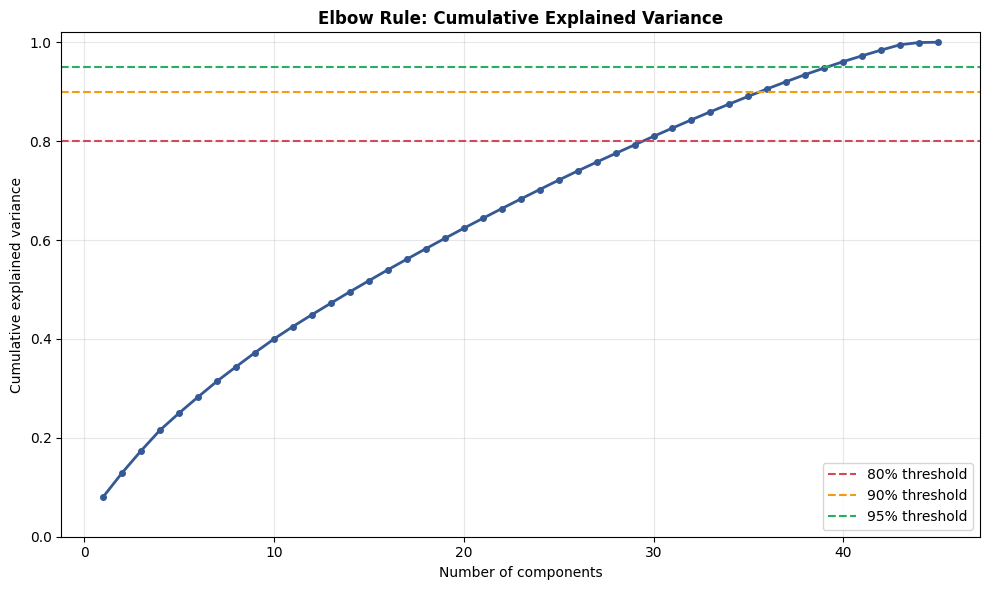

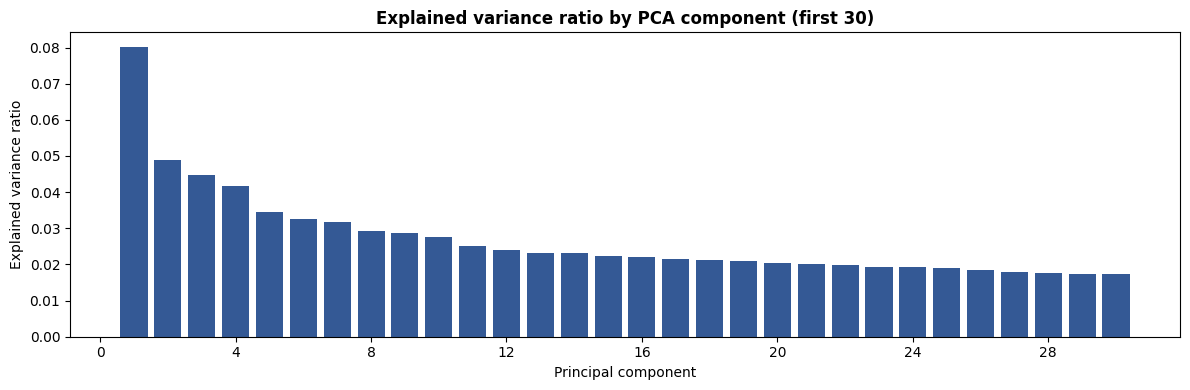

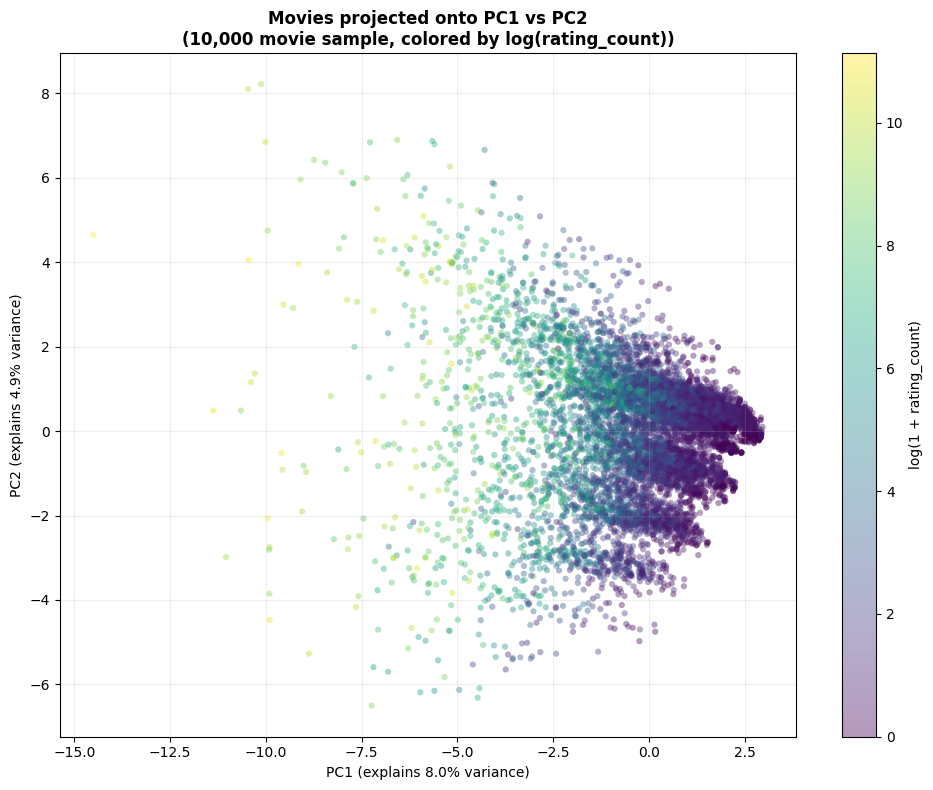

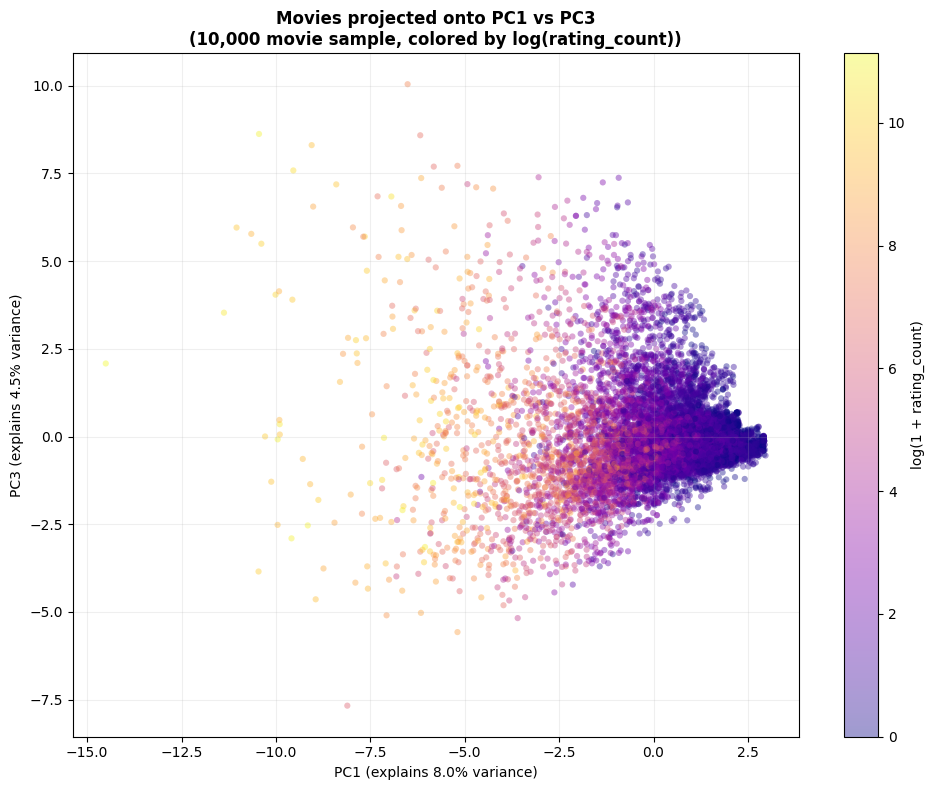

In [9]:
# Plots for the Week 5 report

# 1. Scree plot (elbow rule)
fig, ax = plt.subplots(figsize=(10, 6))
components_range = np.arange(1, min(51, pca_summary_df.height + 1))
cumulative_var = pca_summary_df['cumulative_explained_variance'][:len(components_range)].to_numpy()
ax.plot(components_range, cumulative_var, 'o-', color='#345995', linewidth=2, markersize=4)
ax.axhline(0.80, color='#d1495b', linestyle='--', linewidth=1.5, label='80% threshold')
ax.axhline(0.90, color='#f39c12', linestyle='--', linewidth=1.5, label='90% threshold')
ax.axhline(0.95, color='#27ae60', linestyle='--', linewidth=1.5, label='95% threshold')
ax.set_title('Elbow Rule: Cumulative Explained Variance', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(WEEK05_OUTPUT_DIR / 'week05_pca_elbow_rule.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Explained variance per component (bar chart) - first 30 components
plot_count = min(30, pca_summary_df.height)
component_axis = np.arange(1, plot_count + 1)
variance_values = pca_summary_df['explained_variance_ratio'][:plot_count].to_numpy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(component_axis, variance_values, color='#345995', width=0.8)
ax.set_title('Explained variance ratio by PCA component (first 30)', fontsize=12, fontweight='bold')
ax.set_xlabel('Principal component')
ax.set_ylabel('Explained variance ratio')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
fig.tight_layout()
fig.savefig(WEEK05_OUTPUT_DIR / 'week05_pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Improved PC1 vs PC2 scatter plot with better visualization
sample_size = min(10000, scores_df.height)
rng = np.random.default_rng(42)
sample_idx = rng.choice(scores_df.height, size=sample_size, replace=False)
pc1_sample = scores_df['pc1'].to_numpy()[sample_idx]
pc2_sample = scores_df['pc2'].to_numpy()[sample_idx]
rating_count_sample = feature_frame['rating_count'].to_numpy()[sample_idx]

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(pc1_sample, pc2_sample, c=np.log1p(rating_count_sample),
                     cmap='viridis', s=20, alpha=0.4, edgecolors='none')
ax.set_title(f'Movies projected onto PC1 vs PC2\n({sample_size:,} movie sample, colored by log(rating_count))',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 (explains {explained_variance_ratio[0]:.1%} variance)')
ax.set_ylabel(f'PC2 (explains {explained_variance_ratio[1]:.1%} variance)')
ax.grid(True, alpha=0.2)
colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label('log(1 + rating_count)', fontsize=10)
fig.tight_layout()
fig.savefig(WEEK05_OUTPUT_DIR / 'week05_pca_scatter_pc1_pc2.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. PC1 vs PC3 scatter plot (to see if variance spreads better)
if n_features > 2:
    pc3_sample = scores_df['pc3'].to_numpy()[sample_idx] if 'pc3' in scores_df.columns else (scores @ Vt.T)[sample_idx, 2]

    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(pc1_sample, pc3_sample, c=np.log1p(rating_count_sample),
                         cmap='plasma', s=20, alpha=0.4, edgecolors='none')
    ax.set_title(f'Movies projected onto PC1 vs PC3\n({sample_size:,} movie sample, colored by log(rating_count))',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(f'PC1 (explains {explained_variance_ratio[0]:.1%} variance)')
    ax.set_ylabel(f'PC3 (explains {explained_variance_ratio[2]:.1%} variance)')
    ax.grid(True, alpha=0.2)
    colorbar = fig.colorbar(scatter, ax=ax)
    colorbar.set_label('log(1 + rating_count)', fontsize=10)
    fig.tight_layout()
    fig.savefig(WEEK05_OUTPUT_DIR / 'week05_pca_scatter_pc1_pc3.png', dpi=150, bbox_inches='tight')
    plt.show()

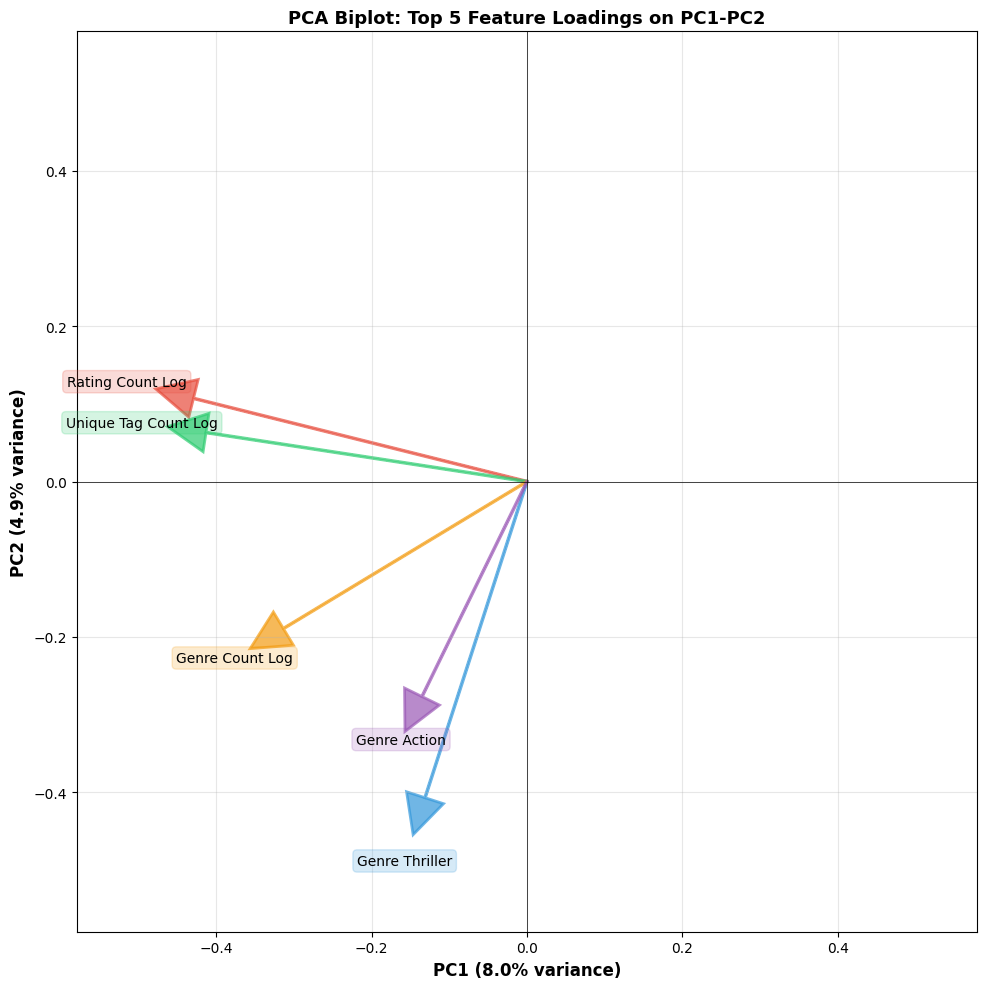


=== Top 5 Features by Loading Magnitude on PC1-PC2 ===
1. rating_count_log                    | PC1: -0.4291 | PC2: +0.1070 | Magnitude: 0.4422
2. genre_thriller                      | PC1: -0.1311 | PC2: -0.4068 | Magnitude: 0.4274
3. unique_tag_count_log                | PC1: -0.4129 | PC2: +0.0630 | Magnitude: 0.4177
4. genre_count_log                     | PC1: -0.3134 | PC2: -0.1892 | Magnitude: 0.3660
5. genre_action                        | PC1: -0.1350 | PC2: -0.2766 | Magnitude: 0.3078


In [10]:
# PCA Biplot: Feature loading vectors on PC1-PC2

# Calculate the magnitude of loadings in PC1-PC2 plane for each feature
loadings_pc1_pc2 = Vt[:2, :].T  # Shape: (n_features, 2)
loading_magnitudes = np.sqrt((loadings_pc1_pc2 ** 2).sum(axis=1))

# Get top 5 features by magnitude in PC1-PC2 space
top_5_indices = np.argsort(loading_magnitudes)[::-1][:5]
top_5_features = [feature_columns[i] for i in top_5_indices]
top_5_loadings = loadings_pc1_pc2[top_5_indices, :]

# Create the biplot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot arrows for each top feature
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for idx, (feature_idx, color) in enumerate(zip(top_5_indices, colors)):
    loading_x = loadings_pc1_pc2[feature_idx, 0]
    loading_y = loadings_pc1_pc2[feature_idx, 1]

    ax.arrow(0, 0, loading_x, loading_y,
             head_width=0.05, head_length=0.05,
             fc=color, ec=color, alpha=0.7, linewidth=2)

    # Add feature label
    label_x = loading_x * 1.2
    label_y = loading_y * 1.2
    ax.text(label_x, label_y, feature_columns[feature_idx].replace('_', ' ').title(),
            fontsize=10, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.2, edgecolor=color))

max_loading = float(np.max(np.abs(loadings_pc1_pc2[top_5_indices, :])))
axis_limit = max(0.45, max_loading * 1.35)
ax.set_xlim(-axis_limit, axis_limit)
ax.set_ylim(-axis_limit, axis_limit)
ax.set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_title('PCA Biplot: Top 5 Feature Loadings on PC1-PC2', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal')

fig.tight_layout()
fig.savefig(WEEK05_OUTPUT_DIR / 'week05_pca_biplot_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the feature importance for reference
print("\n=== Top 5 Features by Loading Magnitude on PC1-PC2 ===")
for rank, (idx, magnitude) in enumerate(zip(top_5_indices, loading_magnitudes[top_5_indices]), 1):
    pc1_loading = loadings_pc1_pc2[idx, 0]
    pc2_loading = loadings_pc1_pc2[idx, 1]
    print(f"{rank}. {feature_columns[idx]:<35} | PC1: {pc1_loading:+.4f} | PC2: {pc2_loading:+.4f} | Magnitude: {magnitude:.4f}")


In [11]:
# Check correlations between similar-looking features

# Get the raw feature matrix (before scaling)
X_raw = X.copy()

# Create a feature name lookup
feature_index_lookup = {name: idx for idx, name in enumerate(feature_columns)}

# Check correlations between potentially redundant features
redundancy_check = [
    ('tag_event_count_log', 'unique_tag_count_log'),
    ('rating_count_log', 'tag_event_count_log'),
    ('rating_count_log', 'avg_rating_z'),
    ('genre_count_log', 'rating_count_log'),
]

print("\n=== Feature Correlation Check ===")
print("(Checking for potential redundancy)\n")

for feat1, feat2 in redundancy_check:
    idx1 = feature_index_lookup.get(feat1)
    idx2 = feature_index_lookup.get(feat2)

    if idx1 is not None and idx2 is not None:
        col1 = X_raw[:, idx1]
        col2 = X_raw[:, idx2]

        # Compute Pearson correlation
        corr = np.corrcoef(col1, col2)[0, 1]

        # Also check the angle between their loading vectors
        load1 = loadings_pc1_pc2[idx1, :]
        load2 = loadings_pc1_pc2[idx2, :]
        cos_angle = np.dot(load1, load2) / (np.linalg.norm(load1) * np.linalg.norm(load2) + 1e-10)
        angle_deg = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))

        print(f"{feat1} <-> {feat2}")
        print(f"  Raw correlation: {corr:.3f}")
        print(f"  Loading vector angle: {angle_deg:.1f}°")
        if abs(corr) > 0.7:
            print(f"  ⚠️  HIGHLY CORRELATED (redundancy risk)\n")
        elif abs(corr) > 0.5:
            print(f"  ⚡ Moderately correlated\n")
        else:
            print(f"  ✓ Independent\n")



=== Feature Correlation Check ===
(Checking for potential redundancy)

rating_count_log <-> avg_rating_z
  Raw correlation: 0.319
  Loading vector angle: 36.0°
  ✓ Independent

genre_count_log <-> rating_count_log
  Raw correlation: 0.290
  Loading vector angle: 45.1°
  ✓ Independent



In [12]:
# Check if genre_count_log and unique_tag_count_log are redundant

genre_count_idx = feature_index_lookup.get('genre_count_log')
unique_tag_count_idx = feature_index_lookup.get('unique_tag_count_log')

if genre_count_idx is not None and unique_tag_count_idx is not None:
    genre_col = X_raw[:, genre_count_idx]
    tag_col = X_raw[:, unique_tag_count_idx]

    corr = np.corrcoef(genre_col, tag_col)[0, 1]

    load1 = loadings_pc1_pc2[genre_count_idx, :]
    load2 = loadings_pc1_pc2[unique_tag_count_idx, :]
    cos_angle = np.dot(load1, load2) / (np.linalg.norm(load1) * np.linalg.norm(load2) + 1e-10)
    angle_deg = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))

    print("\n=== Categorical Diversity Check ===")
    print(f"genre_count_log <-> unique_tag_count_log")
    print(f"  Raw correlation: {corr:.3f}")
    print(f"  Loading vector angle: {angle_deg:.1f}°")
    if abs(corr) > 0.6:
        print(f"  ⚠️  Potentially redundant (both measure diversity)\n")
    else:
        print(f"  ✓ Diverse signals (genres and tags vary independently)\n")



=== Categorical Diversity Check ===
genre_count_log <-> unique_tag_count_log
  Raw correlation: 0.292
  Loading vector angle: 39.8°
  ✓ Diverse signals (genres and tags vary independently)



## 5) Interpretation checklist

After you run the notebook, use the outputs above to answer:
- What do the first two principal components represent?
- How quickly does cumulative explained variance grow?
- How many components reach 90% or 95% retention?
- Which features dominate the top loadings?
- Do popularity, release era, genre, or tag richness explain most of the structure?
- Is reconstruction error low enough to justify compression?


## About SVD and PCA

**Important note**: SVD (Singular Value Decomposition) IS PCA. They're not different methods—SVD is the computational algorithm used to perform PCA. When we decompose $X_{scaled} = U \Sigma V^T$ via SVD:
- The columns of $V^T$ (the right singular vectors) are the principal component directions
- The singular values $\Sigma$ relate to explained variance via $(\Sigma^2) / (n-1)$
- PC scores are computed as $X_{scaled} \cdot V$

So we're doing PCA correctly. The cramped scatter plot in the previous version was due to visualization choices (too many overlapping points). Now we improve it with:
- **Elbow plot**: Shows the point of diminishing returns (where additional components add little variance)
- **Larger sample + transparency**: Makes density patterns visible instead of overplotting
- **Multiple component pairs**: PC1-PC2 and PC1-PC3 to see if data spreads better across different projections


In [17]:
!zip -r /data/interim/week05_v1.zip /data/interim/week05_v1/

  adding: data/interim/week05_v1/ (stored 0%)
  adding: data/interim/week05_v1/week05_pca_scores.parquet (deflated 1%)
  adding: data/interim/week05_v1/week05_pca_top_loadings.csv (deflated 61%)
  adding: data/interim/week05_v1/week05_pca_elbow_rule.png (deflated 14%)
  adding: data/interim/week05_v1/week05_pca_biplot_loadings.png (deflated 12%)
  adding: data/interim/week05_v1/week05_feature_catalog.csv (deflated 74%)
  adding: data/interim/week05_v1/week05_pca_thresholds.csv (deflated 20%)
  adding: data/interim/week05_v1/week05_pca_summary.csv (deflated 49%)
  adding: data/interim/week05_v1/week05_pca_feature_matrix.parquet (deflated 1%)
  adding: data/interim/week05_v1/week05_reconstruction_error.csv (deflated 42%)
  adding: data/interim/week05_v1/week05_pca_explained_variance.png (deflated 23%)
  adding: data/interim/week05_v1/week05_pca_scatter_pc1_pc2.png (deflated 2%)
  adding: data/interim/week05_v1/week05_movie_feature_frame.parquet (deflated 1%)
  adding: data/interim/week05